<a href="https://colab.research.google.com/github/dorhoffman/SWINGPULSE/blob/main/notebooks/05_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

PROJECT_PATH = "/content/drive/MyDrive/SWINGPULSE"

FEATURES_PATH = (
    f"{PROJECT_PATH}/data/features/"
    "SWINGPULSE_FEATURES_DATASET.csv"
)

MODELS_FOLDER = f"{PROJECT_PATH}/models"
REPORT_FOLDER = f"{PROJECT_PATH}/report"

os.makedirs(REPORT_FOLDER, exist_ok=True)

print("Features file:", os.path.exists(FEATURES_PATH))
print("Models folder:", os.path.exists(MODELS_FOLDER))

Mounted at /content/drive
Features file: True
Models folder: True


In [2]:
LOGISTIC_PATH = (
    f"{MODELS_FOLDER}/"
    "logistic_regression_model.joblib"
)

RANDOM_FOREST_PATH = (
    f"{MODELS_FOLDER}/"
    "random_forest_model.joblib"
)

METADATA_PATH = (
    f"{MODELS_FOLDER}/"
    "model_metadata.json"
)

print("Logistic model:", os.path.exists(LOGISTIC_PATH))
print("Random Forest:", os.path.exists(RANDOM_FOREST_PATH))
print("Metadata:", os.path.exists(METADATA_PATH))

Logistic model: True
Random Forest: True
Metadata: True


In [3]:
logistic_model = joblib.load(LOGISTIC_PATH)
random_forest_model = joblib.load(RANDOM_FOREST_PATH)

with open(
    METADATA_PATH,
    "r",
    encoding="utf-8"
) as file:
    metadata = json.load(file)

display(metadata)

{'prediction_horizon': 10,
 'target_return': 0.1,
 'features': ['Daily_Return',
  'Volume_Change',
  'SMA_20',
  'SMA_50',
  'SMA_200',
  'EMA_20',
  'EMA_50',
  'EMA_200',
  'RSI_14',
  'MACD',
  'MACD_Signal',
  'MACD_Histogram',
  'BB_Width',
  'ATR_14',
  'Volatility_20',
  'Price_to_SMA20',
  'Price_to_SMA50',
  'Price_to_EMA20',
  'EMA20_to_EMA50'],
 'train_end_date': '2011-06-17T04:00:00.000000000',
 'test_start_date': '2011-07-01T04:00:00.000000000',
 'train_sample_rows': 500000,
 'test_rows': 1473398}

In [4]:
PREDICTION_HORIZON = metadata["prediction_horizon"]
TARGET_RETURN = metadata["target_return"]
FEATURE_COLUMNS = metadata["features"]

TRAIN_END_DATE = pd.to_datetime(
    metadata["train_end_date"]
)

TEST_START_DATE = pd.to_datetime(
    metadata["test_start_date"]
)

print("Prediction horizon:", PREDICTION_HORIZON)
print("Target return:", TARGET_RETURN)
print("Train end:", TRAIN_END_DATE)
print("Test start:", TEST_START_DATE)
print("Number of features:", len(FEATURE_COLUMNS))

Prediction horizon: 10
Target return: 0.1
Train end: 2011-06-17 04:00:00
Test start: 2011-07-01 04:00:00
Number of features: 19


In [5]:
columns_to_load = [
    "Date",
    "Symbol",
    "Close"
] + FEATURE_COLUMNS

features = pd.read_csv(
    FEATURES_PATH,
    usecols=columns_to_load,
    parse_dates=["Date"],
    low_memory=False
)

print("Loaded shape:", features.shape)
display(features.head())

Loaded shape: (3878687, 22)


,Date,Symbol,Close,Daily_Return,Volume_Change,SMA_20,SMA_50,SMA_200,EMA_20,EMA_50,...,MACD,MACD_Signal,MACD_Histogram,BB_Width,ATR_14,Volatility_20,Price_to_SMA20,Price_to_SMA50,Price_to_EMA20,EMA20_to_EMA50
0,1999-11-18 05:00:00,A,26.794758,NaN,NaN,NaN,NaN,NaN,26.794758,26.794758,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000
1,1999-11-19 05:00:00,A,24.587246,-0.082386,-0.756434,NaN,NaN,NaN,26.584519,26.708189,...,-0.176098,-0.035220,-0.140878,NaN,NaN,NaN,NaN,NaN,0.924871,0.995370
2,1999-11-22 05:00:00,A,26.794758,0.089783,-0.568215,NaN,NaN,NaN,26.604541,26.711584,...,-0.135962,-0.055368,-0.080594,NaN,NaN,NaN,NaN,NaN,1.007150,0.995993
3,1999-11-23 05:00:00,A,24.358870,-0.090909,-0.091558,NaN,NaN,NaN,26.390668,26.619320,...,-0.297282,-0.103751,-0.193531,NaN,NaN,NaN,NaN,NaN,0.923011,0.991410
4,1999-11-24 05:00:00,A,25.005911,0.026563,-0.189500,NaN,NaN,NaN,26.258786,26.556049,...,-0.368669,-0.156735,-0.211935,NaN,NaN,NaN,NaN,NaN,0.952287,0.988806


In [6]:
features[FEATURE_COLUMNS] = (
    features[FEATURE_COLUMNS]
    .replace([np.inf, -np.inf], np.nan)
)

features = (
    features
    .sort_values(["Symbol", "Date"])
    .reset_index(drop=True)
)

print("Data sorted and infinity values replaced.")

Data sorted and infinity values replaced.


In [7]:
features["Future_Close"] = (
    features
    .groupby("Symbol")["Close"]
    .shift(-PREDICTION_HORIZON)
)

features["Future_Return"] = (
    features["Future_Close"] - features["Close"]
) / features["Close"]

features["Target"] = (
    features["Future_Return"] >= TARGET_RETURN
).astype("int8")

In [8]:
model_data = features.dropna(
    subset=(
        FEATURE_COLUMNS
        + ["Future_Close", "Future_Return", "Target"]
    )
).copy()

test_data = model_data[
    model_data["Date"] >= TEST_START_DATE
].copy()

X_test = test_data[FEATURE_COLUMNS]
y_test = test_data["Target"]

print("Test rows:", f"{len(test_data):,}")
print("X_test shape:", X_test.shape)

print("\nTarget distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Test rows: 1,473,398
X_test shape: (1473398, 19)

Target distribution:
Target
0    95.51
1     4.49
Name: proportion, dtype: float64


In [9]:
logistic_predictions = logistic_model.predict(
    X_test
)

logistic_probabilities = logistic_model.predict_proba(
    X_test
)[:, 1]

In [10]:
logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(
        y_test,
        logistic_predictions
    ),
    "Precision": precision_score(
        y_test,
        logistic_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        logistic_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        logistic_predictions,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        logistic_probabilities
    ),
    "PR_AUC": average_precision_score(
        y_test,
        logistic_probabilities
    )
}

display(pd.DataFrame([logistic_results]))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.86084,0.148698,0.44487,0.222893,0.752634,0.16053


In [11]:
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.97      0.88      0.92   1407300
           1       0.15      0.44      0.22     66098

    accuracy                           0.86   1473398
   macro avg       0.56      0.66      0.57   1473398
weighted avg       0.93      0.86      0.89   1473398



In [12]:
rf_predictions = random_forest_model.predict(
    X_test
)

rf_probabilities = random_forest_model.predict_proba(
    X_test
)[:, 1]

In [13]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(
        y_test,
        rf_predictions
    ),
    "Precision": precision_score(
        y_test,
        rf_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        rf_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        rf_predictions,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        rf_probabilities
    ),
    "PR_AUC": average_precision_score(
        y_test,
        rf_probabilities
    )
}

display(pd.DataFrame([rf_results]))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest,0.912956,0.18966,0.287331,0.228496,0.772166,0.154924


In [14]:
print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.97      0.94      0.95   1407300
           1       0.19      0.29      0.23     66098

    accuracy                           0.91   1473398
   macro avg       0.58      0.61      0.59   1473398
weighted avg       0.93      0.91      0.92   1473398



In [15]:
model_comparison = pd.DataFrame([
    logistic_results,
    rf_results
])

model_comparison = (
    model_comparison
    .sort_values(
        by="PR_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    model_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.8608,0.1487,0.4449,0.2229,0.7526,0.1605
1,Random Forest,0.9130,0.1897,0.2873,0.2285,0.7722,0.1549


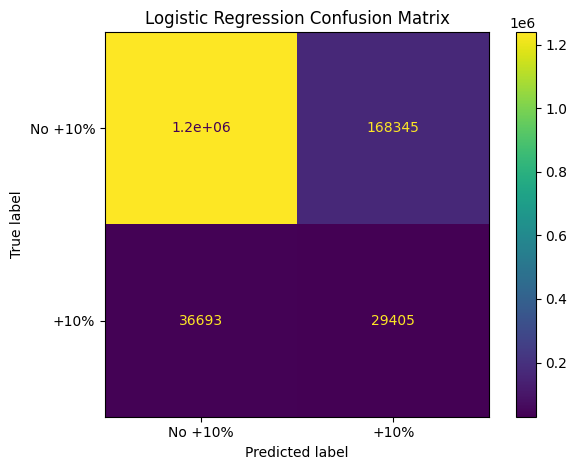

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=["No +10%", "+10%"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

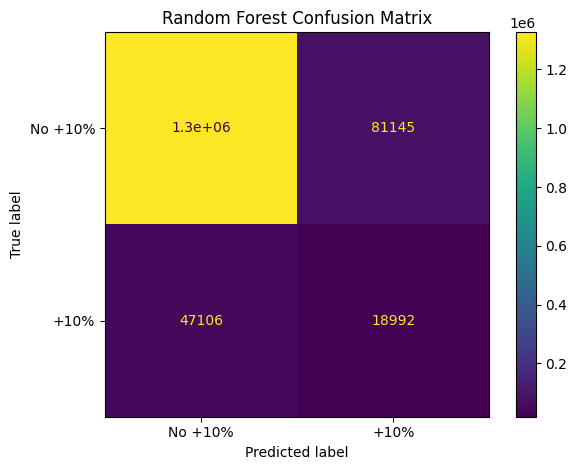

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    display_labels=["No +10%", "+10%"]
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

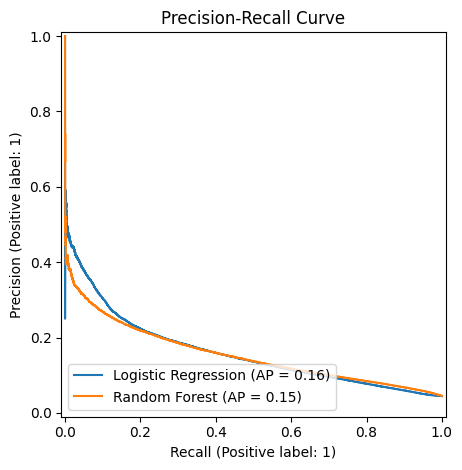

In [18]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    logistic_probabilities,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    rf_probabilities,
    name="Random Forest",
    ax=plt.gca()
)

plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

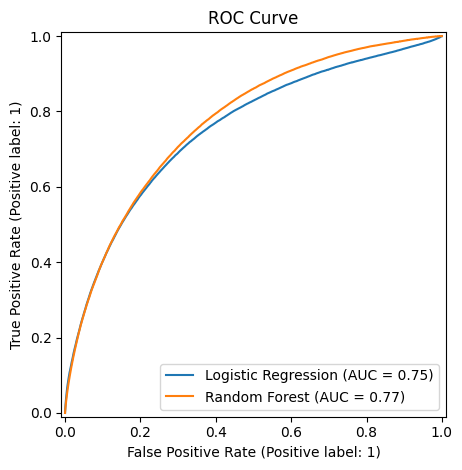

In [19]:
RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_probabilities,
    name="Random Forest",
    ax=plt.gca()
)

plt.title("ROC Curve")
plt.tight_layout()
plt.show()

In [20]:
feature_importance = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Importance": (
        random_forest_model.feature_importances_
    )
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
14,Volatility_20,0.297304
12,BB_Width,0.126500
18,EMA20_to_EMA50,0.072121
16,Price_to_SMA50,0.049260
17,Price_to_EMA20,0.046140
8,RSI_14,0.043582
15,Price_to_SMA20,0.042250
0,Daily_Return,0.040646
13,ATR_14,0.036405
11,MACD_Histogram,0.026653


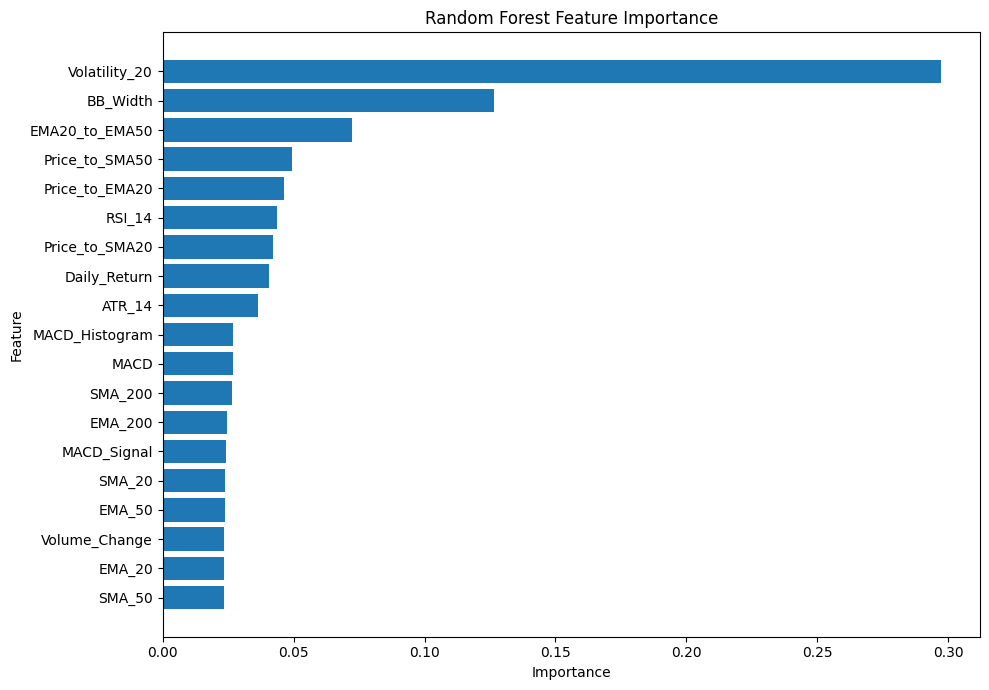

In [21]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [22]:
threshold_results = []

for threshold in [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]:
    predictions = (
        rf_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Positive_Predictions": predictions.sum()
    })

threshold_table = pd.DataFrame(
    threshold_results
)

display(
    threshold_table.style.format({
        "Threshold": "{:.2f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

,Threshold,Precision,Recall,F1,Positive_Predictions
0,0.20,0.0763,0.8516,0.1401,737678
1,0.30,0.1030,0.6846,0.1790,439440
2,0.40,0.1413,0.4809,0.2184,224923
3,0.50,0.1897,0.2873,0.2285,100137
4,0.60,0.2432,0.1417,0.1791,38513
5,0.70,0.3084,0.0528,0.0901,11313


In [23]:
best_model_name = (
    model_comparison
    .iloc[0]["Model"]
)

print(
    "Best model according to PR_AUC:",
    best_model_name
)

Best model according to PR_AUC: Logistic Regression


In [24]:
COMPARISON_PATH = (
    f"{REPORT_FOLDER}/"
    "model_comparison.csv"
)

IMPORTANCE_PATH = (
    f"{REPORT_FOLDER}/"
    "random_forest_feature_importance.csv"
)

THRESHOLD_PATH = (
    f"{REPORT_FOLDER}/"
    "random_forest_threshold_analysis.csv"
)

model_comparison.to_csv(
    COMPARISON_PATH,
    index=False
)

feature_importance.to_csv(
    IMPORTANCE_PATH,
    index=False
)

threshold_table.to_csv(
    THRESHOLD_PATH,
    index=False
)

print("Evaluation results saved:")
print(COMPARISON_PATH)
print(IMPORTANCE_PATH)
print(THRESHOLD_PATH)

Evaluation results saved:
/content/drive/MyDrive/SWINGPULSE/report/model_comparison.csv
/content/drive/MyDrive/SWINGPULSE/report/random_forest_feature_importance.csv
/content/drive/MyDrive/SWINGPULSE/report/random_forest_threshold_analysis.csv
